In [1]:
%matplotlib inline

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import scipy as sp
import cartopy.crs as ccrs
from numba import njit, prange
from tqdm import tqdm

In [3]:
df = pd.read_csv('sdss_cutout.csv')
df

,RA,DEC,Z,phot_u,phot_g,phot_r,phot_i,phot_z
0,130.089951,52.178097,0.097629,19.854843,18.159964,17.345013,16.930433,16.620535
1,130.173909,52.557767,0.067737,19.250399,17.239248,16.517265,16.083832,15.822161
2,130.081237,52.668188,0.063350,18.680342,17.206959,16.697826,16.362032,16.173033
3,130.291706,52.572373,0.065425,19.726742,17.791235,16.906610,16.495539,16.182104
4,130.013537,52.766588,0.123360,19.386818,17.534359,16.450377,15.943369,15.545097
...,...,...,...,...,...,...,...,...
319953,149.580633,47.033396,0.390038,23.223936,19.346468,17.534588,16.857544,16.351515
319954,150.261929,46.827647,0.204686,20.360432,18.511255,17.276648,16.812563,16.496658
319955,149.937963,46.482358,0.102099,19.087252,17.185118,16.237055,15.844631,15.480799
319956,150.023597,46.260926,0.069142,19.072407,17.949339,17.497790,17.227016,17.132250


## Task 1

Text(0.5, 0, 'redshift')

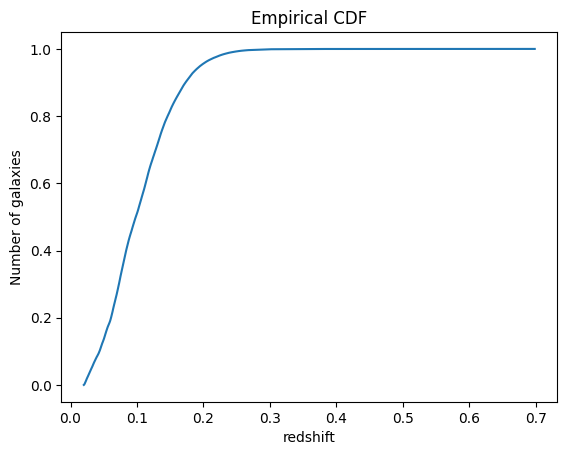

In [4]:
plt.figure()
redshifts = np.sort(df['Z'].values)
plt.plot(redshifts, np.arange(len(redshifts))/len(redshifts))
plt.title('Empirical CDF')
plt.ylabel('Number of galaxies')
plt.xlabel('redshift')

Text(0, 0.5, 'phot_r')

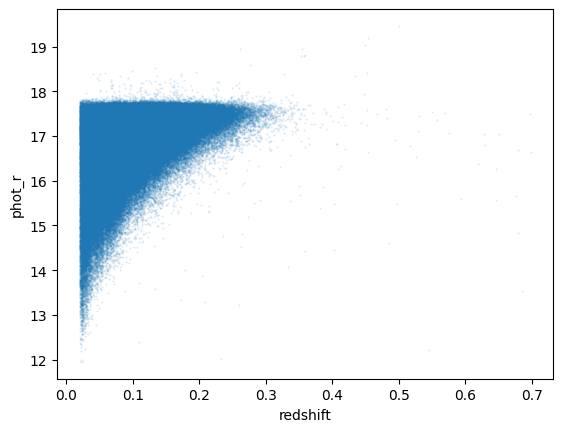

In [5]:
plt.figure()
plt.scatter(df['Z'], df['phot_r'], s=0.5, alpha=0.1)
plt.xlabel('redshift')
plt.ylabel('phot_r')

In [6]:
data_cut = df[(df['Z'] > 0.08) & (df['Z'] < 0.12)].copy()

Text(0, 0.5, 'phot_r')

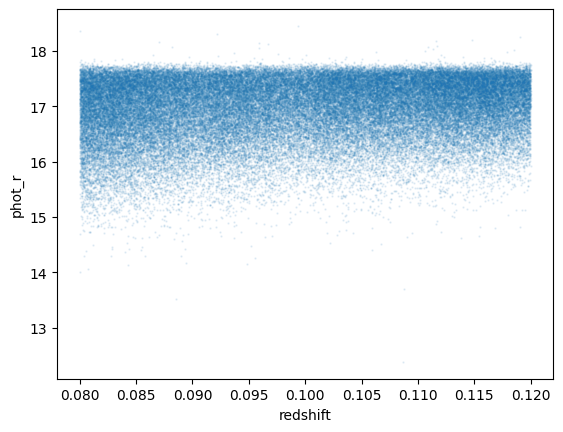

In [7]:
plt.figure()
plt.scatter(data_cut['Z'], data_cut['phot_r'], s=0.5, alpha=0.1)
plt.xlabel('redshift')
plt.ylabel('phot_r')

## Task 2

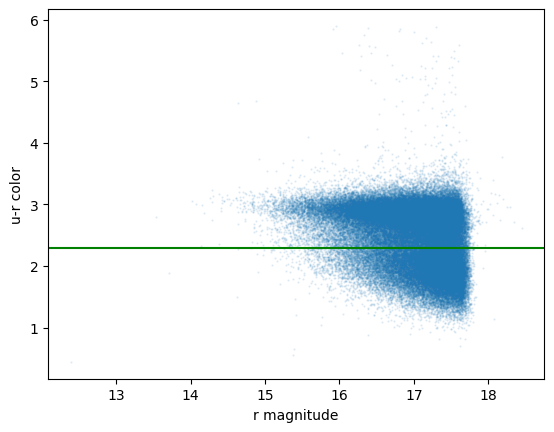

In [8]:
plt.figure()
plt.scatter(data_cut['phot_r'], data_cut['phot_u']-data_cut['phot_r'], s=0.5, alpha=0.1)
plt.xlabel('r magnitude')
plt.ylabel('u-r color')
plt.axhline(2.3, color='green')

In [9]:
data_cut['u-r'] = data_cut['phot_u'] - data_cut['phot_r']

In [10]:
red = data_cut[data_cut['u-r'] > 2.3].copy()
blue = data_cut[data_cut['u-r'] <= 2.3].copy()

## Task 3

In [11]:
print(np.mean(red['phot_r']), '+-', np.std(red['phot_r']))
print(np.mean(blue['phot_r']), '+-', np.std(blue['phot_r']))

16.884902132896993 +- 0.5532295368731545
17.148581973026662 +- 0.4317605611301002


In [12]:
# sp.stats.bootstrap((red['phot_r'].to_numpy(),), np.mean, vectorized=False, n_resamples=1000, confidence_level=0.95, method='percentile')

In [13]:
# sp.stats.bootstrap((blue['phot_r'].to_numpy(),), np.mean, vectorized=False, n_resamples=1000, confidence_level=0.95, method='percentile')

In [14]:
def z_alpha(a):
    return sp.stats.norm.ppf((1+a)/2)

In [15]:
conf_interval = z_alpha(0.95)*np.std(red['phot_r'])/np.sqrt(len(red['phot_r']))

In [16]:
print(conf_interval)
print(conf_interval/z_alpha(0.95))
print(np.mean(red['phot_r'])-conf_interval, np.mean(red['phot_r'])+conf_interval)

0.0044026743807326785
0.00224630371550723
16.88049945851626 16.889304807277725


## Task 4

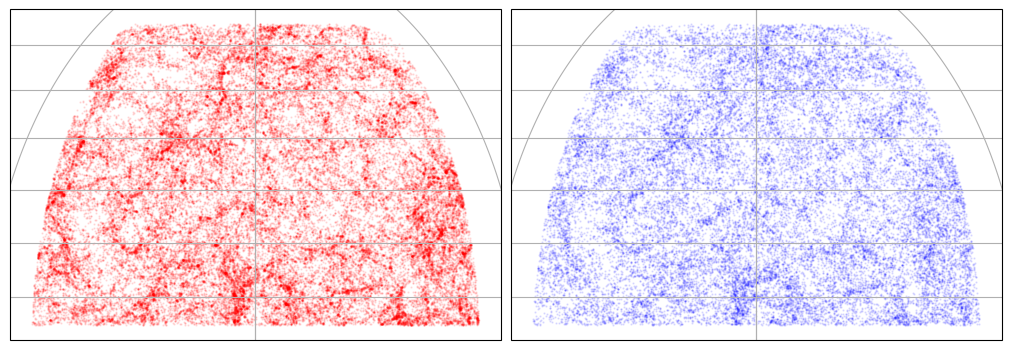

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 15), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax[0].gridlines()
ax[0].scatter(red['RA'], red['DEC'], s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='red')

ax[1].gridlines()
ax[1].scatter(blue['RA'], blue['DEC'], s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='blue')


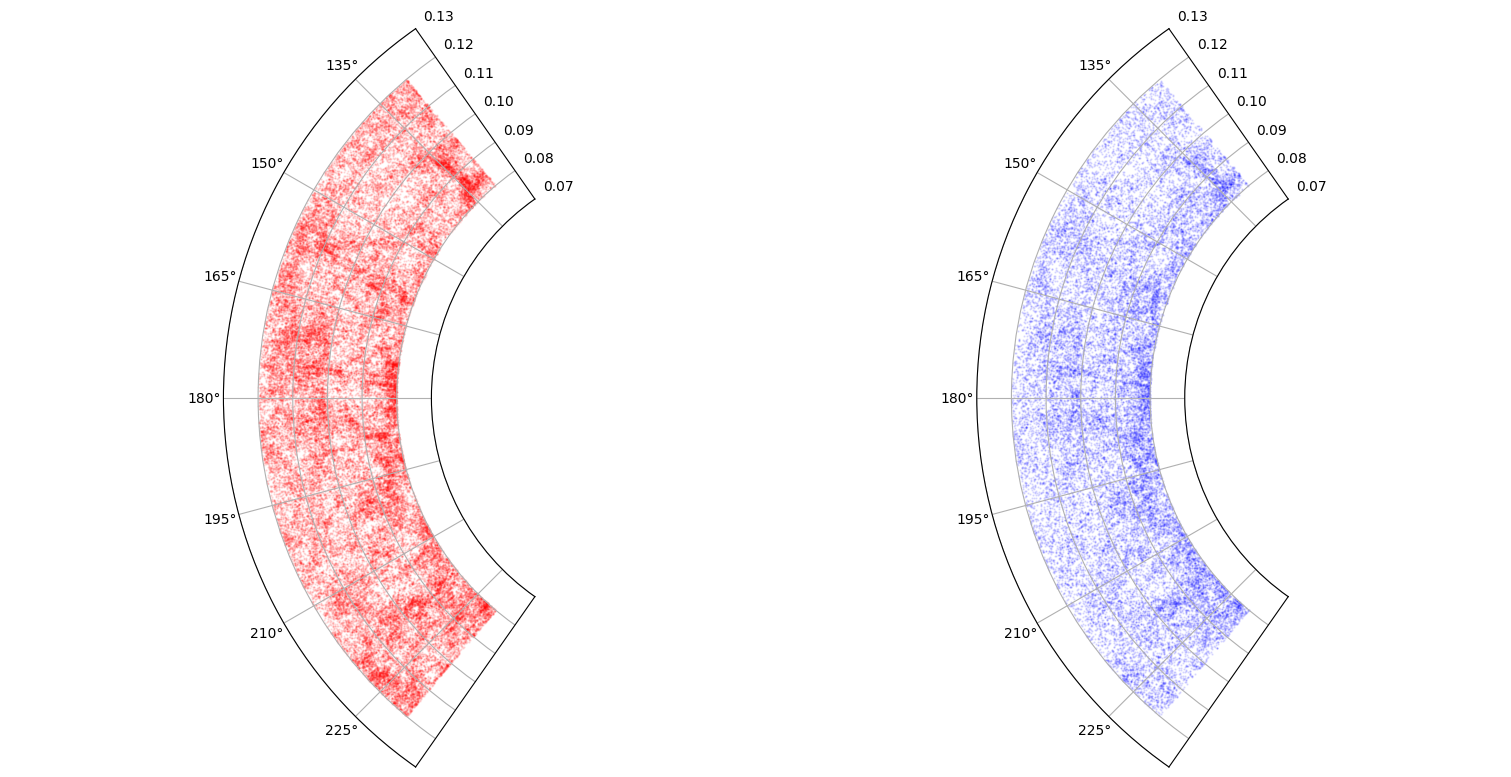

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8), subplot_kw={'projection': 'polar'},
                        layout='constrained')
ax[0].scatter(red['RA']*np.pi/180, red['Z'], s=0.5, alpha=0.1, color='red')
ax[1].scatter(blue['RA']*np.pi/180, blue['Z'], s=0.5, alpha=0.1, color='blue')

ax[0].set_rmax(0.13)
ax[0].set_rmin(0.07)  # Change the radial axis to only go from 0.07 to 0.13
ax[0].set_rorigin(0)  # Set the origin of the radial axis to 0
ax[0].set_thetamin(125)
ax[0].set_thetamax(235)


ax[1].set_rmax(0.13)
ax[1].set_rmin(0.07)  # Change the radial axis to only go from 1 to 2
ax[1].set_rorigin(0)  # Set the origin of the radial axis to 0
ax[1].set_thetamin(125)
ax[1].set_thetamax(235)


## Task 5. Computing the two-point correlation function

### Generate uniform distribution on sphere

Uniform distribution on the cartesian ra/dec grid is not uniform on the sphere. To demonstrate this we created a function which can generate uniformly distributed objects either on cartesian grid or on sperical grid.

In [19]:
def unirand_field(xmin, xmax, ymin, ymax, N=100, sphere=True, unit='rad'):
    if sphere:
        return unirand_sphere(xmin, xmax, ymin, ymax, N, unit)
    else:
        x = np.random.rand(N)*(xmax - xmin) + xmin
        y = np.random.rand(N)*(ymax - ymin) + ymin
        return x, y

We followed this method of generating uniform distribution on spere: https://github.com/CorySimon/CorySimon.github.io/blob/master/_posts/articles/2015-02-27-uniformdistn-on-sphere.md

Changes we made:
1) Add limits to make it possible to cover just part of the sphere.
2) We work with declination instead of polar angle.

In [20]:
def unirand_sphere(ramin, ramax, decmin, decmax, N=100, unit='rad'):
    if unit=='deg':
        ramin, ramax, decmin, decmax = np.deg2rad([ramin, ramax, decmin, decmax])
    elif unit!='rad':
        raise ValueError("unit should be 'rad' or 'dec'")

    ra = np.random.rand(N)*(ramax-ramin) + ramin
    dec_rand_min = (1-np.sin(decmin))/2.
    dec_rand_max = (1-np.sin(decmax))/2.
    dec_rand = np.random.rand(N)*(dec_rand_max - dec_rand_min) + dec_rand_min
    dec = np.pi/2 - np.arccos(1 - 2*dec_rand)

    if unit=='deg':
        ra, dec = np.rad2deg([ra, dec])

    return ra, dec    

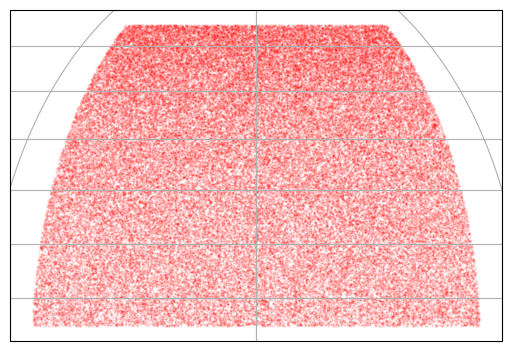

In [21]:
rand_ra, rand_dec = unirand_field(130, 230, 5, 65, len(data_cut), unit='deg', sphere=False)
fig, ax = plt.subplots(1, 1, figsize=(5, 8), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax.gridlines()
ax.scatter(rand_ra, rand_dec, s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='red')

In [22]:
rand_ra, rand_dec = unirand_field(130, 230, 5, 65, len(data_cut), unit='deg', sphere=True)

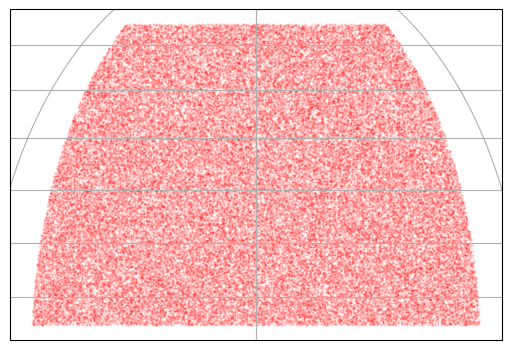

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(5, 8), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax.gridlines()
ax.scatter(rand_ra, rand_dec, s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='red')

In [24]:
general_rand_field = np.array([rand_ra, rand_dec]).T * np.pi/180.

### Optimizing pairs counting

In [25]:
ang_bins = np.geomspace(0.003,0.3,11)

In [26]:
@njit(parallel=True)
def spat_corr(x, y, bins):
    n = np.zeros(len(bins))
    for i in prange(len(x)):
        for j in prange(len(y)):
            sep = dist_sphere(x[i], y[j])
            for k, b in enumerate(bins):
                if sep < b:
                    n[k] = n[k] + 1
                    break
    return n

@njit(parallel=True)
def spat_spec(x, bins):
    n = np.zeros(len(bins))
    for i in prange(len(x)):
        for j in prange(i+1, len(x)):
            sep = dist_sphere(x[i], x[j])
            for k, b in enumerate(bins):
                if sep < b:
                    n[k] = n[k] + 1
                    break
    return n

@njit()
def dist_cart(first, second):
    return np.sqrt((first[0]-second[0])**2 + (first[1]-second[1])**2)

@njit()
def dist_sphere(A, B):
    """
    assumes that every coordinate is [RA(rad), DEC(rad)]
    """
    cos_theta = np.sin(A[1])*np.sin(B[1]) + np.cos(A[1])*np.cos(B[1])*np.cos(A[0]-B[0])
    return np.arccos(cos_theta)

In [27]:
rng = np.random.default_rng()
small_subset = rng.choice(general_rand_field, 10, replace=False)

spat_corr(small_subset, small_subset, ang_bins)
spat_spec(small_subset, ang_bins)

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 7.])

In [28]:
def tp_corr_func_LS(points, bins, M=None, rand_field=None, RR_=None):
    """
    points: ndarray
        2D array, each row is ra-dec coordinate (in rad)
    bins: ndarray
        distance bins for 2D-correlation func
    M: None or int, optional, default=None
        number of points in uniform distribution
    """
    N = len(points)
    # N if M is None, else M
    M = M or N
    if rand_field is None:
        ra_min, dec_min = np.min(points, axis=0)
        ra_max, dec_max = np.max(points, axis=0)
        rand_ra_, rand_dec_ = unirand_field(ra_min, ra_max, dec_min, dec_max, M)
        rand_field = np.array([rand_ra_, rand_dec_]).T
    if RR_ is None:
        RR_ = spat_spec(rand_field, bins)
    DD = spat_spec(points, bins)
    RD = spat_corr(rand_field, points, bins)

    corr = 1 + M*(M-1)*DD/(N*(N-1)*RR_) - (M-1)*RD/(N*RR_)
    return corr 

In [29]:
red_np = np.array([red['RA'].values, red['DEC'].values]).T * np.pi/180.
red_np

array([[2.27049796, 0.91067958],
       [2.28050003, 0.87391945],
       [2.28951282, 0.87932566],
       ...,
       [2.61353364, 0.80825221],
       [2.6099061 , 0.81114086],
       [2.61691112, 0.81127019]], shape=(60656, 2))

In [30]:
rand_ra, rand_dec = unirand_field(130, 230, 5, 65, len(data_cut), unit='deg')
general_rand_field = np.array([rand_ra, rand_dec]).T * np.pi/180.
RR = spat_spec(general_rand_field, ang_bins)

In [31]:
corr_red = tp_corr_func_LS(red_np, ang_bins, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

In [54]:
blue_np = np.array([blue['RA'].values, blue['DEC'].values]).T * np.pi/180.

In [75]:
corr_blue = tp_corr_func_LS(blue_np, ang_bins, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

In [76]:
blue_np_subsample = rng.choice(blue_np, 30456, replace=False)
corr_blue_subsample = tp_corr_func_LS(blue_np_subsample, ang_bins, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

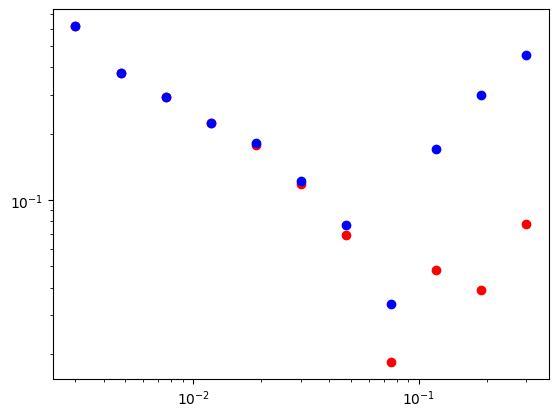

In [78]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'ro')
ax.plot(ang_bins, corr_blue_subsample, 'bo')
ax.set_xscale('log')
ax.set_yscale('log')

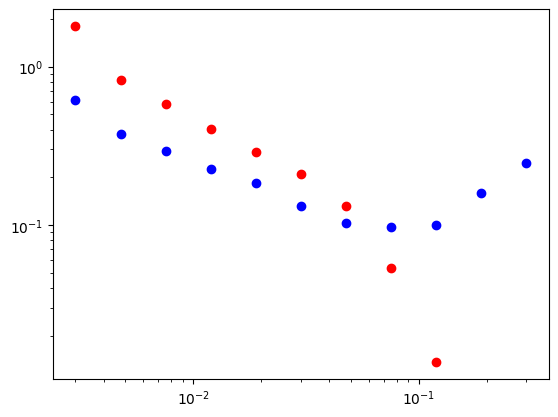

In [74]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_red, 'ro')
ax.plot(ang_bins, corr_blue, 'bo')
ax.set_xscale('log')
ax.set_yscale('log')

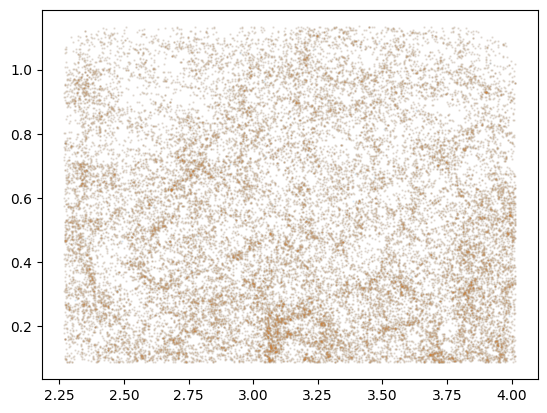

In [68]:
plt.scatter(blue_np[:,0], blue_np[:,1], s=0.5, alpha=0.1)
plt.scatter(blue_np_subsample[:,0], blue_np_subsample[:,1], s=0.5, alpha=0.1)

In [35]:
def jacknife(data, statistics, sub_n=None, itn=10, args=(), **kwargs):
    rng_ = np.random.default_rng()
    N = len(data)
    sub_n = sub_n or N/10

    if not isinstance(sub_n, int):
        try:
            sub_n = int(sub_n)
        except ValueError:
            print("Number of elements in subsample should be integer!")

    if sub_n > N:
        raise ValueError("Subsample should be smaller than full sample!")
            
    if not isinstance(args, tuple):
        args = (args,)
        
    res = []
    for _ in tqdm(range(itn)):
        subsample = rng_.choice(data, sub_n, replace=False)
        res.append(statistics(subsample, *args, **kwargs))
    raw_var = np.var(res, ddof=1, axis=0)
    sigma = np.sqrt(raw_var)
    av = np.mean(res, axis=0)
    return av, sigma, res

In [37]:
corr_red_j, corr_red_err, _ = jacknife(red_np, tp_corr_func_LS, sub_n=60000, args=(ang_bins,), itn=2, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

100%|██████████| 2/2 [06:59<00:00, 209.94s/it]


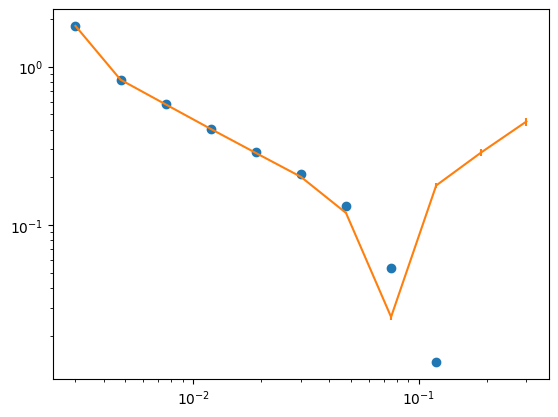

In [38]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_red, 'o')

ax.errorbar(ang_bins, corr_red_j, yerr=corr_red_err)
ax.set_xscale('log')
ax.set_yscale('log')

In [52]:
corr_blue_j, corr_blue_err, jackknife_blue = jacknife(blue_np, tp_corr_func_LS, sub_n=20000, args=(ang_bins,), itn=5, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

100%|██████████| 5/5 [04:51<00:00, 58.34s/it]


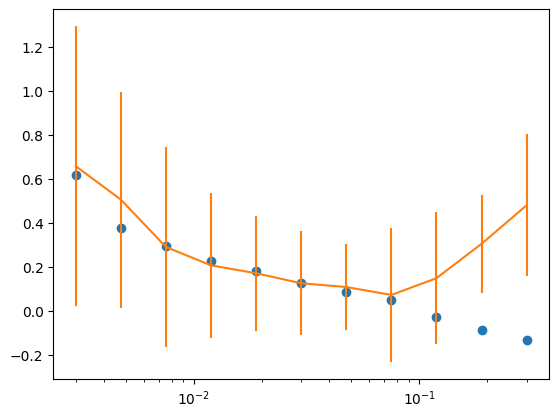

In [46]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
# ax.set_yscale('log')

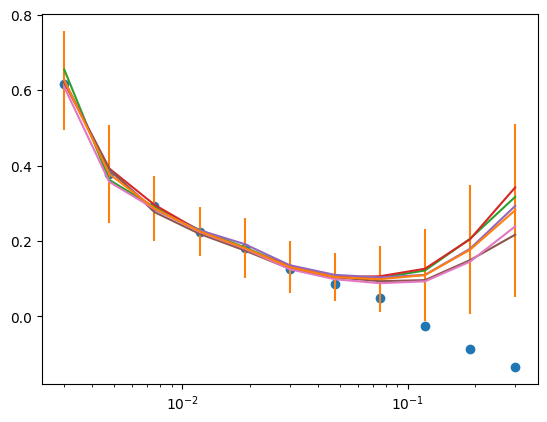

In [53]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')

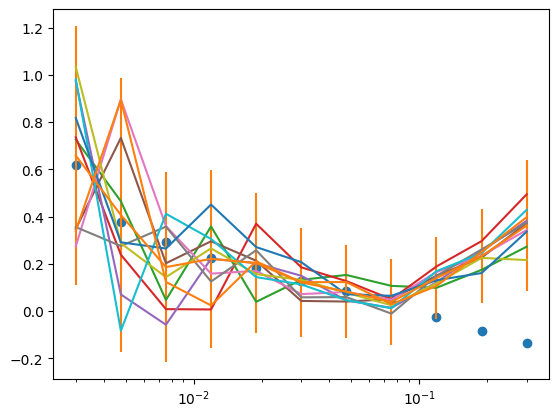

In [51]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')